
## MODULE 1: Foundations of Time Series & Preprocessing
### Dataset: Monthly Car sales
Structure:
-	Load and clean time indexed data
-	Enforce proper frequency
-	Visualize and decompose a series
-	Test for stationarity using the ADF and KPSS tests
-	Engineer lag features for modeling


## 1. Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Load dataset

In [14]:
file_path = "../data/monthly-car-sales.csv"
df = pd.read_csv(file_path, sep="\t")
print(df.shape)

print(df.columns)

df.head()

(108, 1)
Index(['Month,"Sales"'], dtype='object')


,"Month,""Sales"""
0,"1960-01,6550"
1,"1960-02,8728"
2,"1960-03,12026"
3,"1960-04,14395"
4,"1960-05,14587"


## 3. Split the combined column

In [15]:

df = df.iloc[:, 0].str.split(",", expand=True)
df.columns = ["Month", "Sales"]
df

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587
...,...,...
103,1968-08,16722
104,1968-09,14385
105,1968-10,21342
106,1968-11,17180


## 4. Convert types

In [16]:
# Step 1: Parse datetime and set index
df["Month"] = pd.to_datetime(df["Month"])
df["Sales"] = pd.to_numeric(df["Sales"])

df.set_index("Month", inplace=True)

# Step 2: Defensive Audit - Check for Duplicate Timestamps (Slide 17)
duplicates = df.index.duplicated().sum()
print(duplicates)

0


## 5. Enforce monthly frequency

In [17]:
# Enforcing 'MS' (Month Start) ensures no hidden timeline gaps exist
df = df.asfreq("MS")

## 6. Handle missing values

In [18]:
# Data Integrity & Structural Imputation Check 
missing_values = df.isna().sum().sum()
print(missing_values)

0


In [19]:
if missing_values > 0:
    # If values were missing, we use structural interpolation, NEVER drop rows!
    df["Sales"] = df["Sales"].interpolate(method="linear")
    print("Timeline gap resolved via linear structural interpolation.")
else:
    print("Data integrity verified. No structural imputation required.")

Data integrity verified. No structural imputation required.


## 7. Visualization

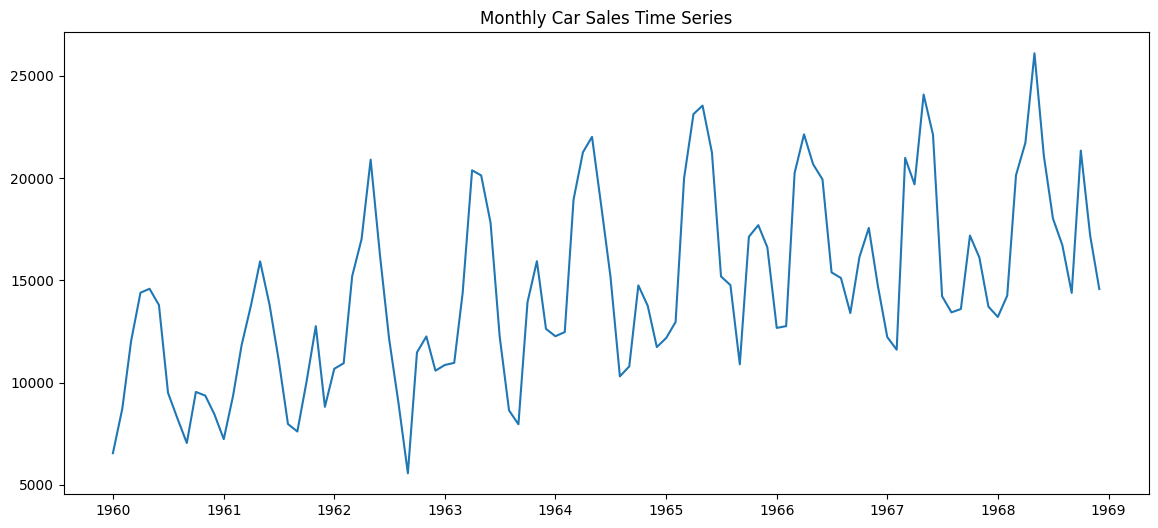

In [20]:

plt.plot(df["Sales"])
plt.title("Monthly Car Sales Time Series")
plt.show()

## 8. Decomposition

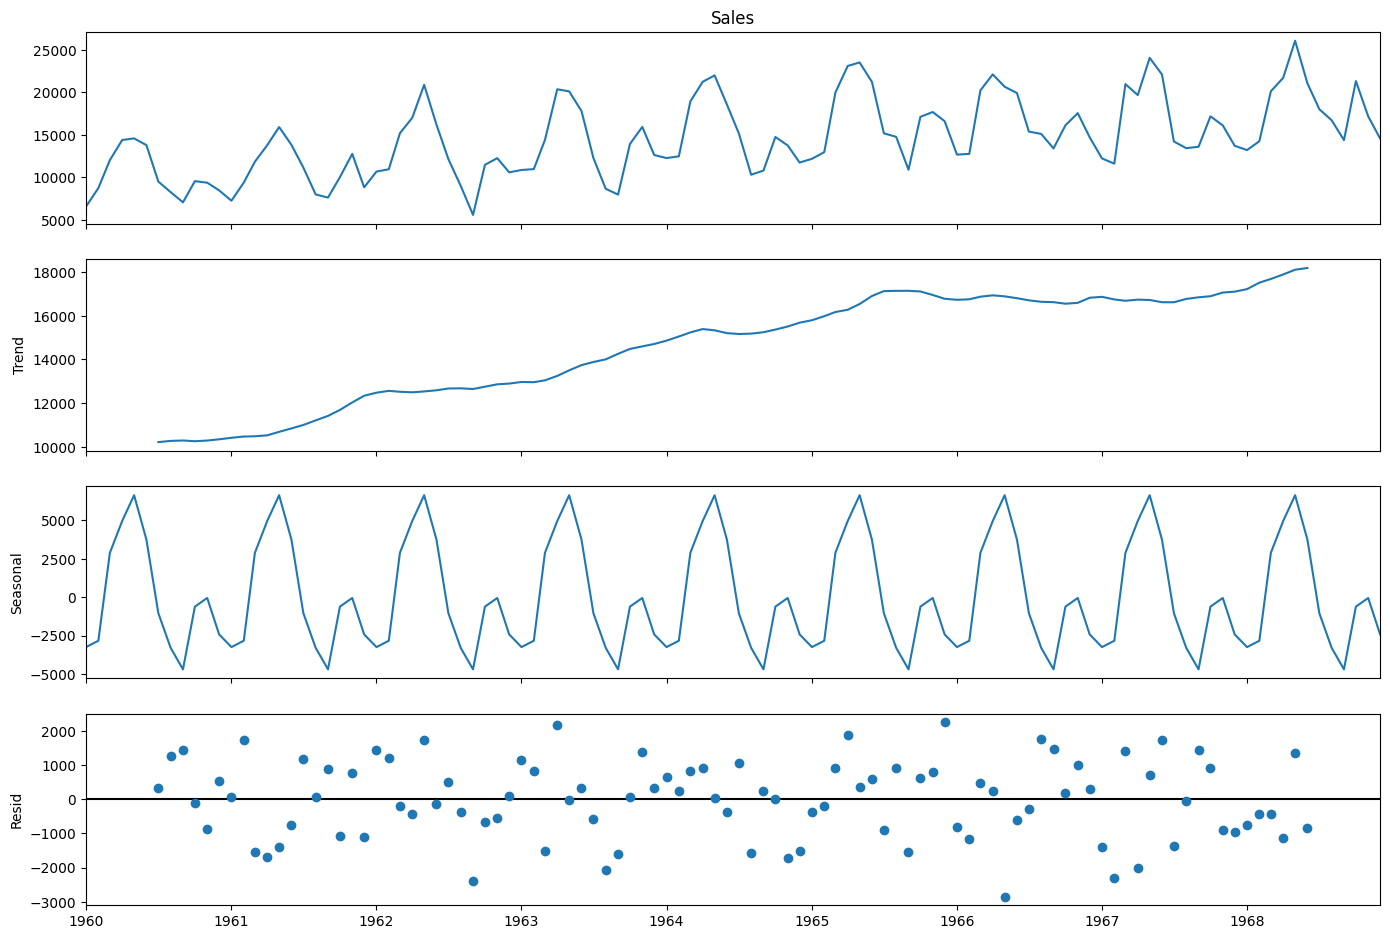

In [21]:


result = seasonal_decompose(df["Sales"], model="additive")
result.plot().set_size_inches(14, 10)
plt.show()

## 9. Stationary check
### Interpretation Rules

- **ADF p-value > 0.05 → Non‑stationary**
- **KPSS p-value < 0.05 → Non‑stationary**

If both tests say non‑stationary →  
✔ The series is **definitely non‑stationary** and needs differencing.

In [22]:
# ADF Test -> ADF p-value > 0.05 → NON‑stationary
adf_result = adfuller(df["Sales"])
print("ADF P-value:", adf_result[1])

ADF P-value: 0.6632691049832861


In [23]:
# KPSS Test ->  p-value < 0.05 → NON‑stationary
kpss_result = kpss(df["Sales"], regression="c")
print("KPSS P-value:", kpss_result[1])

KPSS P-value: 0.01


C:\Users\oadsa\AppData\Local\Temp\ipykernel_23508\3008500798.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df["Sales"], regression="c")


Summary:

| ADF Result | KPSS Result | Interpretation |
| --- | --- | --- |
| Non‑stationary | Non‑stationary | **Definitely non‑stationary** |
| Stationary | Stationary | **Definitely stationary** |
| Stationary | Non‑stationary | **Trend‑stationary** |
| Non‑stationary | Stationary | **Difference‑stationary** |

## 10. Feature Engineering : Creating Lags

In [24]:

demo_df = df.copy()
demo_df['Lag_1'] = demo_df['Sales'].shift(1)
demo_df['Lag_2'] = demo_df['Sales'].shift(2)
print(demo_df.head())

            Sales    Lag_1    Lag_2
Month                              
1960-01-01   6550      NaN      NaN
1960-02-01   8728   6550.0      NaN
1960-03-01  12026   8728.0   6550.0
1960-04-01  14395  12026.0   8728.0
1960-05-01  14587  14395.0  12026.0


### Final Conclusion

Both ADF and KPSS tests indicate that the Monthly Car Sales series is **non‑stationary**.  
This means the data has trend and/or seasonality and must be transformed (usually by differencing) before modeling.

